# Introdução aos Notebooks Jupyter

## Carregar uma imagem da internet

In [1]:
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
from PIL import Image

In [4]:
img_path = "Cat03.jpg"

In [5]:
!wget https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg

/bin/bash: warning: setlocale: LC_ALL: cannot change locale (pt_BR.UTF-8)
--2025-10-07 15:56:39--  https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 2a02:ec80:700:ed1a::2:b, 195.200.68.240
Connecting to upload.wikimedia.org (upload.wikimedia.org)|2a02:ec80:700:ed1a::2:b|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 279603 (273K) [image/jpeg]
Saving to: 'Cat03.jpg.6'

Cat03.jpg.6         100%[===================>] 273.05K  1.73MB/s    in 0.2s    

2025-10-07 15:56:40 (1.73 MB/s) - 'Cat03.jpg.6' saved [279603/279603]



In [6]:
img_path = "Cat03.jpg"
img = Image.open(img_path)

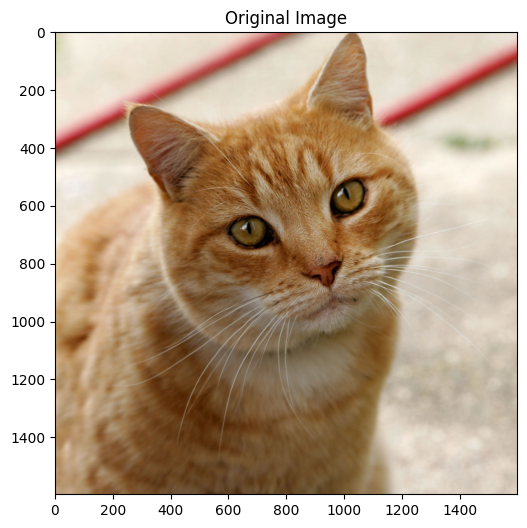

In [7]:
# Exibir a imagem
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title("Original Image")
plt.show()

## Capturando uma Imagem com a **Camera**

In [8]:
# importar as bibliotecas
from picamera2 import Picamera2
from time import sleep


In [9]:
# Inicializar a câmera
camera = Picamera2()
camera.start()
sleep(2) # Pausa para a câmera aquecer e ajustar o foco/exposição

[1:05:15.631986219] [2483]  INFO Camera camera_manager.cpp:297 libcamera v0.0.5+83-bde9b04f
[1:05:15.682087053] [2502]  WARN RPI vc4.cpp:383 Mismatch between Unicam and CamHelper for embedded data usage!
[1:05:15.683188513] [2502]  INFO RPI vc4.cpp:437 Registered camera /base/soc/i2c0mux/i2c@1/imx219@10 to Unicam device /dev/media3 and ISP device /dev/media0
[1:05:15.683260075] [2502]  INFO RPI pipeline_base.cpp:1101 Using configuration file '/usr/share/libcamera/pipeline/rpi/vc4/rpi_apps.yaml'
[1:05:15.699763999] [2483]  INFO Camera camera.cpp:1033 configuring streams: (0) 640x480-XBGR8888 (1) 640x480-SBGGR10_CSI2P
[1:05:15.700613063] [2502]  INFO RPI vc4.cpp:565 Sensor: /base/soc/i2c0mux/i2c@1/imx219@10 - Selected sensor format: 640x480-SBGGR10_1X10 - Selected unicam format: 640x480-pBAA


In [ ]:
try:
    # 1. Capturar a imagem para um objeto Pillow em memória
    pil_image = camera.capture_image("main")

    # 2. Converter a imagem de RGBA para RGB (remove o canal de transparência)
    print("Convertendo imagem para RGB...")
    rgb_image = pil_image.convert("RGB")

    # 3. Salvar a imagem convertida
    file_path = "test.jpg"
    rgb_image.save(file_path)
    print(f"Imagem capturada e salva em: {file_path}")

finally:
    # Sempre pare a câmera ao final
    camera.stop()

img_path = "test.jpg"
img = Image.open(img_path)
# Exibir a imagem
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title("Original Image")
plt.show()    